# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [ ]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob
import string

# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
    os.chdir('..')

### Read Files

In [16]:
# Read all csv files in climate_experiments folder
#path = os.getcwd() + '/climate_experiments/'
path = '/Users/sophiekim/Desktop/2_research/sophie_codes/climate_experiments'
csvs = glob.glob(os.path.join(path, "*.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)
summaries

[   scenario  early_yr  late_yr  mean_pred  accuracy
 0    ssp119      2015     2025   0.470245      0.82
 1    ssp119      2015     2035   0.410600      0.84
 2    ssp119      2015     2045   0.466150      0.98
 3    ssp119      2015     2055   0.430172      0.90
 4    ssp119      2015     2065   0.532195      0.92
 5    ssp119      2015     2075   0.595301      0.90
 6    ssp119      2015     2085   0.489195      0.68
 7    ssp119      2025     2035   0.541241      0.66
 8    ssp119      2025     2045   0.540277      0.74
 9    ssp119      2025     2055   0.572211      0.70
 10   ssp119      2025     2065   0.642615      0.50
 11   ssp119      2025     2075   0.616965      0.50
 12   ssp119      2025     2085   0.587658      0.48
 13   ssp119      2035     2045   0.531505      0.56
 14   ssp119      2035     2055   0.485640      0.50
 15   ssp119      2035     2065   0.473414      0.72
 16   ssp119      2035     2075   0.578257      0.62
 17   ssp119      2035     2085   0.512858    

### Calculations

In [25]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries, scenario):
    # Make a df to hold: 
    # a) metadata
    acc_df = pd.DataFrame(columns=['scenario'])
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early_yr']
    acc_df['late'] = summaries[0]['late_yr']
    
    # b) accuracies
    for i in range(len(csvs)):
        acc_df[f"acc_{i}"] = summaries[i]['accuracy']
    
    # c) mean and std
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    acc_df['std'] = acc_df[acc_cols].std(axis=1)

    # Drop the accuracy columns
    mean_std = acc_df.drop(columns=acc_cols)
    mean_std = mean_std[mean_std['scenario'] == scenario]
    
    return mean_std

In [26]:
mean_std_119 = get_mean_std(summaries, "ssp119")
mean_std_119

,scenario,early,late,mean,std
0,ssp119,2015,2025,0.853333,0.030551
1,ssp119,2015,2035,0.766667,0.238607
2,ssp119,2015,2045,0.806667,0.266333
3,ssp119,2015,2055,0.933333,0.030551
4,ssp119,2015,2065,0.846667,0.181475
5,ssp119,2015,2075,0.780000,0.243311
6,ssp119,2015,2085,0.660000,0.350428
7,ssp119,2025,2035,0.706667,0.098658
8,ssp119,2025,2045,0.773333,0.041633
9,ssp119,2025,2055,0.813333,0.133167


In [27]:
mean_std_126 = get_mean_std(summaries, "ssp126")
mean_std_126

,scenario,early,late,mean,std
28,ssp126,2015,2025,0.813333,0.061101
29,ssp126,2015,2035,0.953333,0.064291
30,ssp126,2015,2045,0.960000,0.020000
31,ssp126,2015,2055,0.913333,0.115470
32,ssp126,2015,2065,0.953333,0.064291
33,ssp126,2015,2075,0.993333,0.011547
34,ssp126,2015,2085,0.960000,0.069282
35,ssp126,2025,2035,0.826667,0.070238
36,ssp126,2025,2045,0.806667,0.144684
37,ssp126,2025,2055,0.886667,0.057735


### Making a Matrix

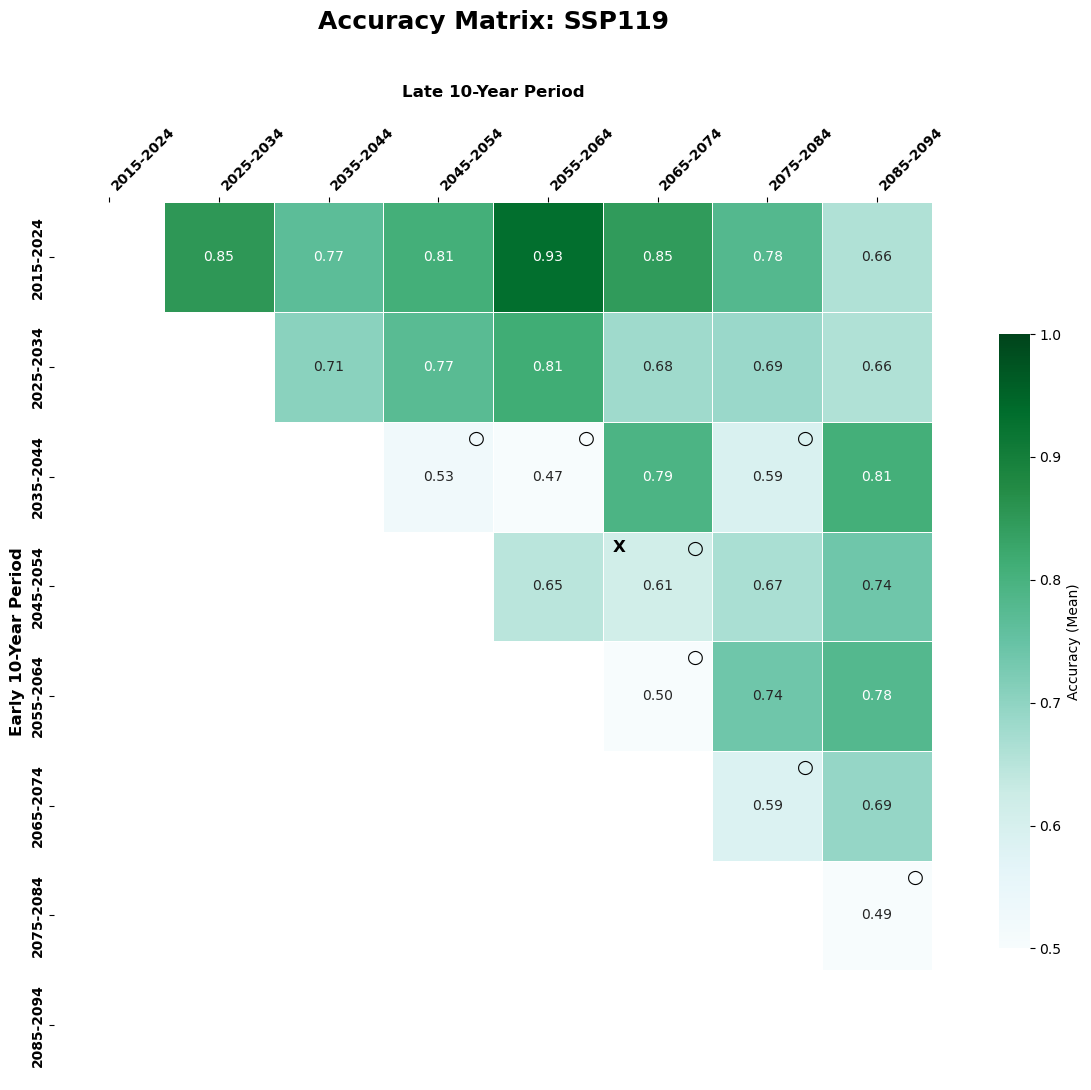

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_unbinned_matrix(df, scenario_id="ssp119"):
    # 1. Load your results

    
    # union to find the unique years for early and late start years 
    all_years = sorted(list(set(df['early'].unique()) | set(df['late'].unique())))
    
    # making df for matrix 
    matrix_df = df.pivot_table(
        index='early', # rows are early start yrs 
        columns='late', # cols are the late start yrs 
        values='mean', 
        aggfunc='mean'# avgs the accuracy for multiple csvs 
    )
    
    # ensures that only cells with unique yr combos are there and everything else is nothing 
    matrix_df = matrix_df.reindex(index=all_years, columns=all_years)
    
    # labeling 
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    matrix_df.index = labels
    matrix_df.columns = labels

    # PLOT
    plt.figure(figsize=(14, 11))
    
    # create boolean lower triangle filter 
    # k=0 hides the diagonal cells 
    mask = np.tril(np.ones_like(matrix_df, dtype=bool), k=0)

    ax = sns.heatmap(
        matrix_df, 
        mask=mask, 
        cmap='BuGn', 
        annot=True, 
        fmt=".2f", 
        square=True, 
        linewidths=.5,
        cbar_kws={"shrink": .7, "label": "Accuracy (Mean)"},
        vmin=0.5, vmax=1.0 # 0.5 = random guessing
    )
    # 6. Logic for X and Circle Markers
    # We iterate through every row (y) and column (x)
    for y in range(len(matrix_df.index)):
        for x in range(len(matrix_df.columns)):
            val = matrix_df.iloc[y, x]
            
            # Only process visible (unmasked) cells with actual data
            if not mask[y, x] and not pd.isna(val):
                if 0.60 <= val <= 0.64:
                    ax.text(x + 0.15, y + 0.15, 'X', color='black', 
                            ha='center', va='center', fontweight='bold', fontsize=12)
                if val <= 0.64:
                    ax.text(x + 0.85, y + 0.15, '○', color='black', 
                            ha='center', va='center', fontweight='bold', fontsize=14)
                    
                # Condition 1: Accuracy <= 0.60 (X in top-left)
                
                
                # Condition 2: Accuracy <= 0.64 (Circle in top-right)
                
                    
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left', fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.xlabel("Late 10-Year Period", fontsize=12, fontweight='bold', labelpad=20)
    plt.ylabel("Early 10-Year Period", fontsize=12, fontweight='bold')
    plt.title(f"Accuracy Matrix: {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()

plot_unbinned_matrix(mean_std_119, scenario_id="ssp119")

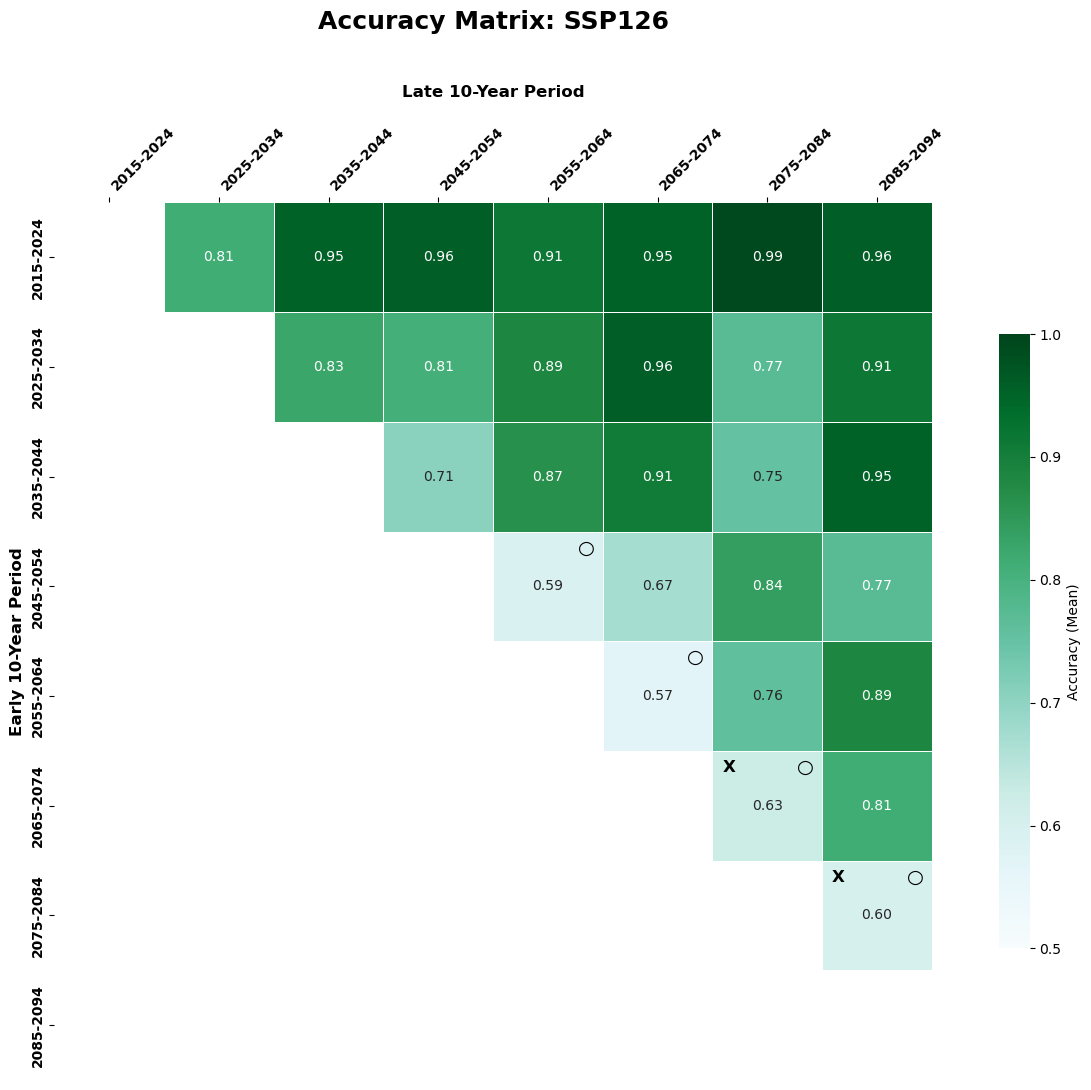

In [29]:
plot_unbinned_matrix(mean_std_126, scenario_id="ssp126")